**DANIEL YU & JORDAN WANG**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 4: Train ConvPCNs on CIFAR-10

The focus of this week is to train several ConvPCN nets and analyze the effect of He/Kaiming initialization and Group Normalization. Finally, you will train a deeper ConvPCN to strive for high classification accuracy on CIFAR-10 🚀.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

2026-04-08 00:52:23.184727: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 00:52:24.193019: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Task 9: The effect of weight initialization and GroupNorm when training ConvPCN on CIFAR-10 

Now we are ready to build a convolutional PC network and train it on CIFAR-10! 🎉 Woohoo 🎉!!

In [2]:
from conv_pcn import ConvPCN6Mini

### 9a. Build and test `ConvPC6Mini`

Let's build and test a PCN that we will call `ConvPCN6Mini` in `conv_pcn.py` with:
- 1 solo `Conv2D` layer at the start of the network
- 3 ConvPCNBlocks
- 1 dense hidden layer
- 1 output layer

See the class docstring for specifics.

#### Test: Print network architecture

In [3]:
pcnet = ConvPCN6Mini(input_feats_shape=(32, 32, 3), C=5, dropout_rate=None, wt_init='he')
pcnet.compile()

2026-04-08 00:52:30.556030: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20601 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


2026-04-08 00:52:31.524928: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90400


---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 5]
Dense layer output(Dense_Hidden) shape: [1, 128]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(Maxpool2D_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2D layer output(FFConv2D) shape: [1, 8, 8, 192]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 8, 8, 128]
MaxPool2D layer output(Maxpool2D_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2D layer output(FFConv2D) shape: [1, 16, 16, 128]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 16, 16, 64]
MaxPool2D layer output(Maxpool2D_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2D layer output(FFConv2D) shape: [1, 32, 32, 64]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D) shape: [1, 32, 32, 64]
---------------------------------------------------------------------------


You should see the following above:

```
---------------------------------------------------------------------------
Dense layer output(Output) shape: [1, 5]
Dense layer output(Dense_Hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 3072]
Flatten layer output(Flatten) shape: [1, 3072]
MaxPool2D layer output(Maxpool2D_2) shape: [1, 4, 4, 192]
PCNBlock_2:
	Conv2D layer output(FFConv2D) shape: [1, 8, 8, 192]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 8, 8, 128]
MaxPool2D layer output(Maxpool2D_1) shape: [1, 8, 8, 128]
PCNBlock_1:
	Conv2D layer output(FFConv2D) shape: [1, 16, 16, 128]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 16, 16, 64]
MaxPool2D layer output(Maxpool2D_0) shape: [1, 16, 16, 64]
PCNBlock_0:
	Conv2D layer output(FFConv2D) shape: [1, 32, 32, 64]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 32, 32, 64]
Conv2D layer output(Conv2D) shape: [1, 32, 32, 64]
---------------------------------------------------------------------------
```

#### Overfit test

Download the CIFAR-10 dev set from the project website and run the code below to load it in. *The dev set is already preprocessed so it should be ready for use.*

To test whether your net is working properly, we will perform an overfit test on a small amount of the CIFAR-10 data. Train your `ConvPCN6Mini` on the dev set with default hyperparameters except for:
- `50` epochs
- Group norm and He initialization turned on.
- Set the mini-batch size accordingly...

Make a plot showing the training loss over epochs. If your net is working properly, you should see the loss plummet to ≤0.05 within the 50 epochs.

**Note:** If your code assumes a val set is present, set the dev set also as the val set for this test.

In [4]:
# KEEP ME
cifar_dev = np.load('data/cifar10_dev.npz')
x_dev = tf.constant(cifar_dev['x_dev'], dtype=tf.float32)
y_dev = tf.constant(cifar_dev['y_dev'], dtype=tf.int32)
print('CIFAR-10 dev set info:')
print(f'{x_dev.shape=} {y_dev.shape=}')
print(f'{x_dev.dtype=} {y_dev.dtype=}')

CIFAR-10 dev set info:
x_dev.shape=TensorShape([20, 32, 32, 3]) y_dev.shape=TensorShape([20])
x_dev.dtype=tf.float32 y_dev.dtype=tf.int32


I0000 00:00:1775609565.611960     843 service.cc:145] XLA service 0x5cf3e4b9a060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775609565.611995     843 service.cc:153]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9


2026-04-08 00:52:45.874406: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1775609575.057729     843 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 0/49, Training loss 2.910520, Val loss 2.229553, Val acc 0.2000
Epoch 0 took: 25.5 secs
Epoch 1/49, Training loss 2.258819, Val loss 1.936760, Val acc 0.4000
Epoch 1 took: 0.0 secs
Epoch 2/49, Training loss 2.167621, Val loss 1.861224, Val acc 0.6000
Epoch 2 took: 0.0 secs
Epoch 3/49, Training loss 1.700046, Val loss 1.779980, Val acc 0.5000
Epoch 3 took: 0.0 secs
Epoch 4/49, Training loss 1.885054, Val loss 1.713966, Val acc 0.5500
Epoch 4 took: 0.0 secs
Epoch 5/49, Training loss 1.719243, Val loss 1.678522, Val acc 0.5000
Epoch 5 took: 0.0 secs
Epoch 6/49, Training loss 1.761325, Val loss 1.616497, Val acc 0.5000
Epoch 6 took: 0.0 secs
Epoch 7/49, Training loss 1.344148, Val loss 1.568236, Val acc 0.5000
Epoch 7 took: 0.0 secs
Epoch 8/49, Training loss 1.468713, Val loss 1.425832, Val acc 0.5500
Epoch 8 took: 0.0 secs
Epoch 9/49, Training loss 1.337698, Val loss 1.305915, Val acc 0.5500
Epoch 9 took: 0.0 secs
Epoch 10/49, Training loss 1.245731, Val loss 1.220055, Val acc 0.650

Epoch 12/49, Training loss 1.441476, Val loss 1.023148, Val acc 0.8500
Epoch 12 took: 0.0 secs
Epoch 13/49, Training loss 1.119440, Val loss 0.910516, Val acc 0.9000
Epoch 13 took: 0.0 secs
Epoch 14/49, Training loss 0.779909, Val loss 0.812906, Val acc 0.9000
Epoch 14 took: 0.0 secs
Epoch 15/49, Training loss 0.759121, Val loss 0.727621, Val acc 0.9000
Epoch 15 took: 0.0 secs
Epoch 16/49, Training loss 0.800525, Val loss 0.631164, Val acc 0.9000
Epoch 16 took: 0.0 secs
Epoch 17/49, Training loss 0.649392, Val loss 0.533736, Val acc 0.9500
Epoch 17 took: 0.0 secs
Epoch 18/49, Training loss 0.519730, Val loss 0.448227, Val acc 1.0000
Epoch 18 took: 0.0 secs
Epoch 19/49, Training loss 0.420926, Val loss 0.363281, Val acc 1.0000
Epoch 19 took: 0.0 secs
Epoch 20/49, Training loss 0.357371, Val loss 0.292127, Val acc 1.0000
Epoch 20 took: 0.0 secs
Epoch 21/49, Training loss 0.300709, Val loss 0.251621, Val acc 1.0000
Epoch 21 took: 0.0 secs
Epoch 22/49, Training loss 0.220043, Val loss 0.22

Epoch 24/49, Training loss 0.189444, Val loss 0.142321, Val acc 1.0000
Epoch 24 took: 0.0 secs
Epoch 25/49, Training loss 0.167255, Val loss 0.119053, Val acc 1.0000
Epoch 25 took: 0.0 secs
Epoch 26/49, Training loss 0.123722, Val loss 0.103242, Val acc 1.0000
Epoch 26 took: 0.0 secs
Epoch 27/49, Training loss 0.105691, Val loss 0.088604, Val acc 1.0000
Epoch 27 took: 0.0 secs
Epoch 28/49, Training loss 0.070945, Val loss 0.080345, Val acc 1.0000
Epoch 28 took: 0.0 secs
Epoch 29/49, Training loss 0.079279, Val loss 0.068732, Val acc 1.0000
Epoch 29 took: 0.0 secs
Epoch 30/49, Training loss 0.074939, Val loss 0.057054, Val acc 1.0000
Epoch 30 took: 0.0 secs
Epoch 31/49, Training loss 0.056850, Val loss 0.048051, Val acc 1.0000
Epoch 31 took: 0.0 secs
Epoch 32/49, Training loss 0.051073, Val loss 0.041912, Val acc 1.0000
Epoch 32 took: 0.0 secs
Epoch 33/49, Training loss 0.047616, Val loss 0.037500, Val acc 1.0000
Epoch 33 took: 0.0 secs
Epoch 34/49, Training loss 0.038163, Val loss 0.03

Epoch 36/49, Training loss 0.032162, Val loss 0.028696, Val acc 1.0000
Epoch 36 took: 0.0 secs
Epoch 37/49, Training loss 0.030620, Val loss 0.026697, Val acc 1.0000
Epoch 37 took: 0.0 secs
Epoch 38/49, Training loss 0.025729, Val loss 0.025189, Val acc 1.0000
Epoch 38 took: 0.0 secs
Epoch 39/49, Training loss 0.024542, Val loss 0.023855, Val acc 1.0000
Epoch 39 took: 0.0 secs
Epoch 40/49, Training loss 0.020092, Val loss 0.022703, Val acc 1.0000
Epoch 40 took: 0.0 secs
Epoch 41/49, Training loss 0.023320, Val loss 0.021652, Val acc 1.0000
Epoch 41 took: 0.0 secs
Epoch 42/49, Training loss 0.024128, Val loss 0.020428, Val acc 1.0000
Epoch 42 took: 0.0 secs
Epoch 43/49, Training loss 0.022869, Val loss 0.018703, Val acc 1.0000
Epoch 43 took: 0.0 secs
Epoch 44/49, Training loss 0.016410, Val loss 0.017355, Val acc 1.0000
Epoch 44 took: 0.0 secs
Epoch 45/49, Training loss 0.016117, Val loss 0.016166, Val acc 1.0000
Epoch 45 took: 0.0 secs
Epoch 46/49, Training loss 0.013139, Val loss 0.01

Epoch 48/49, Training loss 0.011902, Val loss 0.013849, Val acc 1.0000
Epoch 48 took: 0.0 secs
Epoch 49/49, Training loss 0.013327, Val loss 0.013324, Val acc 1.0000
Epoch 49 took: 0.0 secs
Finished training after 50 epochs!


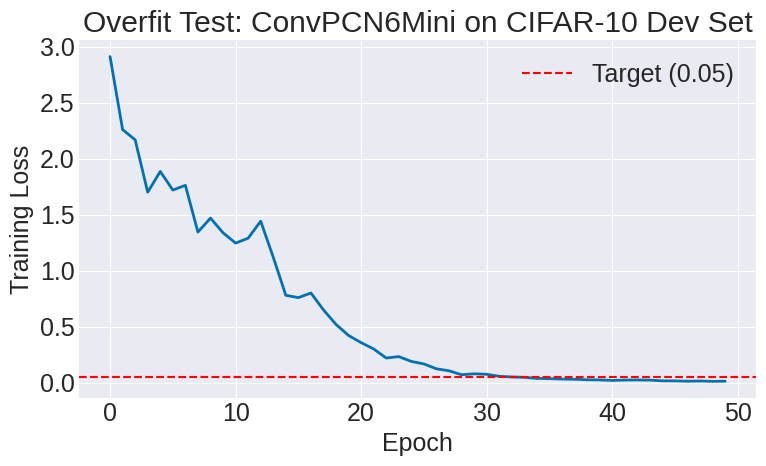

Final training loss: 0.0133


In [5]:
# Overfit test: train on dev set for 50 epochs with He init + group norm
tf.random.set_seed(0)
pcnet_overfit = ConvPCN6Mini(
    input_feats_shape=(32, 32, 3),
    C=10,
    dropout_rate=None,
    wt_init='he',
    do_group_norm=True
)
pcnet_overfit.compile(loss='cross_entropy', lr=1e-3, print_summary=False)

# Use dev set as both train and val (as instructed)
train_loss_overfit, _, _, _ = pcnet_overfit.fit(
    x_dev, y_dev,
    x_val=x_dev, y_val=y_dev,
    batch_size=len(y_dev),   # full-batch since dev set is small
    max_epochs=50,
    patience=999,
    lr_patience=999,
    verbose=True,
    print_every=5
)

# Plot training loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_loss_overfit, linewidth=2)
ax.axhline(0.05, color='red', linestyle='--', label='Target (0.05)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Overfit Test: ConvPCN6Mini on CIFAR-10 Dev Set')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Final training loss: {train_loss_overfit[-1]:.4f}')

### 9b. Weight initialization and group norm CIAR-10 experiment

Let's run an experiment to see how the different weight initialization strategies (`'normal'` vs `'he'`) and group norm components of the model affect classification accuracy and speed of learning when training on CIFAR-10.

Train `ConvPC6Mini` with the following 3 configurations below:
1. Normal weight initialization, no group norm
2. He weight initialization, no group norm
3. He weight initialization, group norm

Make 3 high-quality plots to summarize the results of the simulation experiment:
1. training loss over epochs for the 3 nets.
2. val loss over epochs for the 3 nets.
3. val accuracy over epochs for the 3 nets.

Use default hyperparameters to train each of your networks except for:
- `30` training epochs.
- learning rate of `1e-4` (or try `1e-5` if network #2 does not make any training progress).

**Note:**
- When you import CIFAR-10, use the default `'global'` normalization approach.
- Remember that we are now training a CNN so you do NOT want to draw on the flattened features.
- Each network should take 5-10 minutes to train on the GPU.

In [6]:
from image_datasets import get_dataset, train_val_split

In [7]:
# Load and preprocess CIFAR-10 (NOT flattened — we need spatial dims for CNNs)
x_train_full, y_train_full, x_test, y_test = get_dataset('cifar10', norm_method='global', flatten=False)
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full, prop_val=0.1)
print(f'Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}')

Dataset: cifar10
x_train: (50000, 32, 32, 3) <dtype: 'float32'>
y_train: (50000,) <dtype: 'uint8'>
x_test:  (10000, 32, 32, 3) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [8]:
import os
os.makedirs('figs', exist_ok=True)

configs = [
    {'wt_init': 'normal', 'do_group_norm': False, 'label': '1. Normal init, no GroupNorm',  'lr': 1e-4},
    {'wt_init': 'he',     'do_group_norm': False, 'label': '2. He init, no GroupNorm',       'lr': 1e-4},
    {'wt_init': 'he',     'do_group_norm': True,  'label': '3. He init + GroupNorm',          'lr': 1e-4},
]

results = []

for cfg in configs:
    print(f"\n{'='*60}")
    print(f"Training: {cfg['label']}")
    print('='*60)

    tf.random.set_seed(42)
    net = ConvPCN6Mini(
        input_feats_shape=(32, 32, 3),
        C=10,
        dropout_rate=0.2,
        wt_init=cfg['wt_init'],
        do_group_norm=cfg['do_group_norm']
    )
    net.compile(loss='cross_entropy', lr=cfg['lr'], print_summary=False)

    train_loss, val_loss, val_acc, _ = net.fit(
        x_train, y_train,
        x_val=x_val, y_val=y_val,
        batch_size=256,
        max_epochs=20,
        patience=999,
        lr_patience=999,
        verbose=True,
        print_every=5
    )
    results.append({
        'label':      cfg['label'],
        'train_loss': train_loss,
        'val_loss':   val_loss,
        'val_acc':    val_acc,
        'net':        net
    })
    print(f"Final val acc: {val_acc[-1]:.4f}")


Training: 1. Normal init, no GroupNorm


W0000 00:00:1775609586.908587     843 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. cond/random_uniform/RandomUniform


Epoch 0/19, Training loss 2.302588, Val loss 2.302610, Val acc 0.1007
Epoch 0 took: 34.3 secs


Epoch 1/19, Training loss 2.302581, Val loss 2.302640, Val acc 0.0939
Epoch 1 took: 22.6 secs


Epoch 2/19, Training loss 2.302593, Val loss 2.302641, Val acc 0.0939
Epoch 2 took: 22.7 secs


...

Epoch 15/19, Training loss 0.556454, Val loss 0.802494, Val acc 0.7304
Epoch 15 took: 28.7 secs


Epoch 16/19, Training loss 0.526357, Val loss 0.828384, Val acc 0.7227
Epoch 16 took: 28.7 secs


Epoch 17/19, Training loss 0.503541, Val loss 0.796390, Val acc 0.7342
Epoch 17 took: 28.7 secs


Epoch 18/19, Training loss 0.480464, Val loss 0.804960, Val acc 0.7334
Epoch 18 took: 28.7 secs


Epoch 19/19, Training loss 0.454782, Val loss 0.775828, Val acc 0.7516
Epoch 19 took: 28.7 secs
Finished training after 20 epochs!
Final val acc: 0.7516


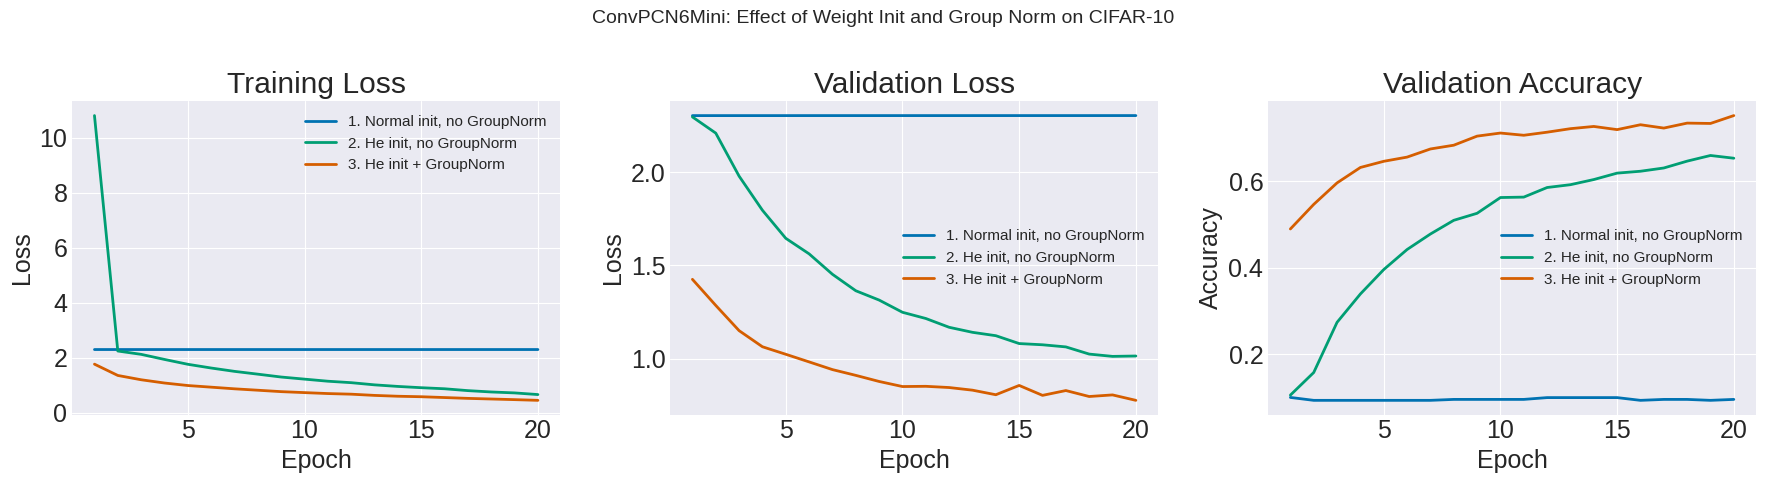

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in results:
    epochs = range(1, len(r['train_loss']) + 1)
    axes[0].plot(epochs, r['train_loss'], linewidth=2, label=r['label'])
    axes[1].plot(epochs, r['val_loss'],   linewidth=2, label=r['label'])
    axes[2].plot(epochs, r['val_acc'],    linewidth=2, label=r['label'])

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Loss', 'Validation Accuracy'],
    ['Loss', 'Loss', 'Accuracy']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=11)

plt.suptitle('ConvPCN6Mini: Effect of Weight Init and Group Norm on CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

### Analysis: Effect of Weight Initialization and Group Normalization

**Configuration 1 — Normal initialization, no GroupNorm:**  
With standard normal initialization, the network fails to learn effectively. The training and validation loss remain flat at around 2.3 (close to random guessing for 10 classes), and validation accuracy stays near 10% throughout training. This indicates that gradients are too small for meaningful updates, causing learning to stall completely. This configuration demonstrates the importance of proper weight initialization in deep networks.

**Configuration 2 — He initialization, no GroupNorm:**  
Using He initialization significantly improves training dynamics. The training loss decreases steadily, and validation accuracy rises quickly, reaching around 70%. This shows that scaling weights based on fan_in helps maintain stable activation variance across layers, enabling effective gradient flow. However, after about 10–15 epochs, validation loss begins to plateau and slightly increase, suggesting mild overfitting despite continued improvements in training loss.

**Configuration 3 — He initialization + GroupNorm:**  
Adding Group Normalization on top of He initialization leads to the best overall performance. This configuration achieves faster initial convergence than He initialization alone and reaches the highest validation accuracy (~75–76%). The validation loss is consistently lower and more stable, indicating improved generalization. GroupNorm helps maintain well-scaled activations throughout training, reducing sensitivity to weight magnitudes and stabilizing gradient updates.

**Key takeaway:** He initialization is essential for enabling learning in deep networks, as it prevents vanishing gradients and allows the model to train effectively. Group Normalization further improves performance by stabilizing activations and gradients during training, leading to faster convergence and better generalization. However, this comes at the cost of increased computational overhead, resulting in longer training times.

In [10]:
print('Final validation accuracies after 30 epochs:')
for r in results:
    print(f"  {r['label']}: {r['val_acc'][-1]*100:.2f}%")

Final validation accuracies after 30 epochs:
  1. Normal init, no GroupNorm: 9.61%
  2. He init, no GroupNorm: 65.31%
  3. He init + GroupNorm: 75.16%


## Task 10: Build, train, and evaluate larger ConvPCN on CIFAR-10

For fun, let's push the convolutional PCN architecture further and train an even larger net on CIFAR-10 that we will call `ConvPCN7XL` composed of the following:

- 1 solo `Conv2D` layer at the beginning of the network
- 4 ConvPCNBlocks
- 1 dense hidden layer
- 1 output layer

Your goal is to implement and train the network with default hyperparameters (including learning rate) except for the following:
- batch size of `64`
- patience of `7`
- learning rate patience of `3` (`3` max decays)
- Group norm and He initialization turned on

Make 2 high-quality plots showing
1. the training and validation loss over epochs
2. the validation acc over epochs

Print out the accuracy on the CIFAR-10 test set.

**Note:** This is expected to take some time to train, likely 60 mins+ on the GPU.


*Your network should do VERY well, way better than any network we have explored thus far!* 😊

In [11]:
from conv_pcn import ConvPCN7XL

In [12]:
# Build and compile ConvPCN7XL
tf.random.set_seed(42)
pcnet_xl = ConvPCN7XL(
    input_feats_shape=(32, 32, 3),
    C=10
)
pcnet_xl.compile(loss='cross_entropy', lr=1e-3, print_summary=True)

---------------------------------------------------------------------------
Dense layer output(Dense_output) shape: [1, 10]
Dense layer output(Dense_hidden) shape: [1, 128]
Dropout layer output(Dropout) shape: [1, 16384]
Flatten layer output(Flatten) shape: [1, 16384]
MaxPool2D layer output(Maxpool2D_3) shape: [1, 8, 8, 256]
PCNBlock_3:
	Dropout layer output(PCNBlock_3_Dropout) shape: [1, 16, 16, 256]
	Conv2D layer output(FFConv2D) shape: [1, 16, 16, 256]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 16, 16, 256]
MaxPool2D layer output(Maxpool2D_2) shape: [1, 16, 16, 256]
PCNBlock_2:
	Dropout layer output(PCNBlock_2_Dropout) shape: [1, 32, 32, 256]
	Conv2D layer output(FFConv2D) shape: [1, 32, 32, 256]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 32, 32, 128]
PCNBlock_1:
	Dropout layer output(PCNBlock_1_Dropout) shape: [1, 32, 32, 128]
	Conv2D layer output(FFConv2D) shape: [1, 32, 32, 128]
	Conv2DTranspose layer output(FBConv2D) shape: [1, 32, 32, 128]
PCNBlock_0:
	Dropout l

In [13]:
# Train ConvPCN7XL on full CIFAR-10 training set
train_loss_xl, val_loss_xl, val_acc_xl, _ = pcnet_xl.fit(
    x_train, y_train,
    x_val=x_val, y_val=y_val,
    batch_size=64,
    max_epochs=100,
    patience=7,
    lr_patience=3,
    lr_max_decays=3,
    verbose=True,
    print_every=1
)

Epoch 0/99, Training loss 1.582735, Val loss 1.209622, Val acc 0.5615
Epoch 0 took: 217.4 secs


Epoch 1/99, Training loss 0.989996, Val loss 0.901419, Val acc 0.6853
Epoch 1 took: 178.5 secs


Epoch 2/99, Training loss 0.729346, Val loss 0.771688, Val acc 0.7273
Epoch 2 took: 178.3 secs


Epoch 3/99, Training loss 0.574522, Val loss 0.664056, Val acc 0.7745
Epoch 3 took: 178.3 secs


Epoch 4/99, Training loss 0.460848, Val loss 0.630473, Val acc 0.7828
Epoch 4 took: 178.1 secs


...

Learning rate before decay: <tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=0.001>
Learning rate after decay: <tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=0.0005>
Epoch 9/99, Training loss 0.137412, Val loss 0.625898, Val acc 0.8188
Epoch 9 took: 177.8 secs


Epoch 10/99, Training loss 0.074729, Val loss 0.590254, Val acc 0.8325
Epoch 10 took: 177.8 secs


Epoch 11/99, Training loss 0.050088, Val loss 0.629162, Val acc 0.8317
Epoch 11 took: 177.8 secs


Epoch 12/99, Training loss 0.040603, Val loss 0.622760, Val acc 0.8360
Epoch 12 took: 177.8 secs


Learning rate before decay: <tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=0.0005>
Learning rate after decay: <tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=0.00025>
Epoch 13/99, Training loss 0.032811, Val loss 0.664748, Val acc 0.8256
Stopping early at epoch 13
Finished training after 14 epochs!


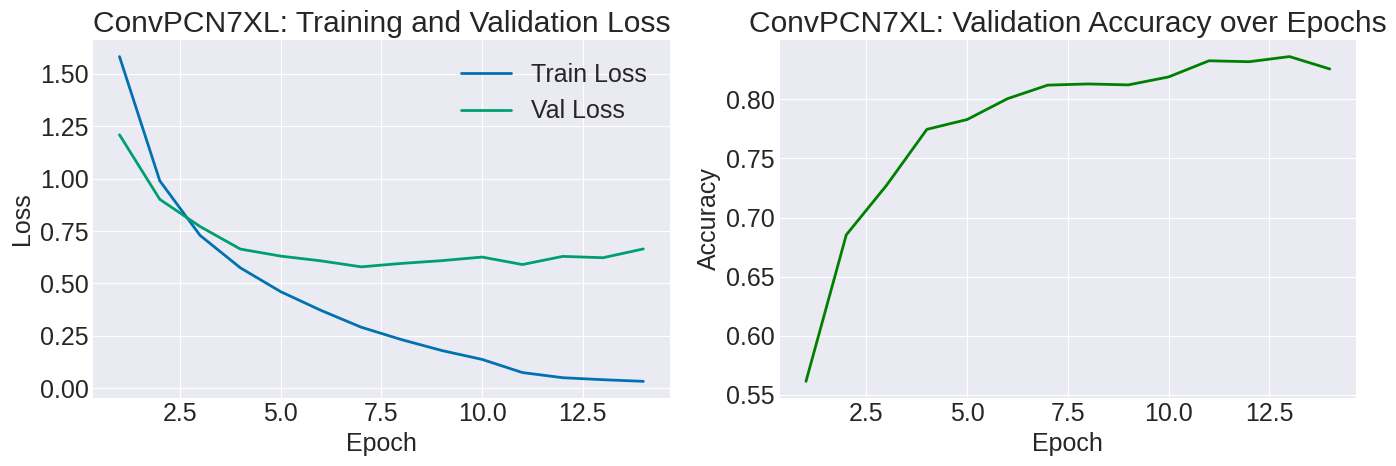


ConvPCN7XL Test Set Accuracy: 65.93%
ConvPCN7XL Best Val Accuracy:  83.60%


In [16]:
# Plot training and validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(train_loss_xl) + 1)
axes[0].plot(epochs, train_loss_xl, linewidth=2, label='Train Loss')
axes[0].plot(epochs, val_loss_xl,   linewidth=2, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ConvPCN7XL: Training and Validation Loss')
axes[0].legend()

axes[1].plot(epochs, val_acc_xl, linewidth=2, color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ConvPCN7XL: Validation Accuracy over Epochs')

plt.tight_layout()
plt.show()

# Evaluate on test set
# _, test_loss, test_acc, _ = pcnet_xl.test_step(x_test, y_test)

batch_size = 64
test_accs = []

for i in range(0, len(x_test), batch_size):
    _, acc = pcnet_xl.test_step(x_test[i:i+batch_size], y_test[i:i+batch_size])
    test_accs.append(float(acc))

test_acc = sum(test_accs) / len(test_accs)

print(f'\nConvPCN7XL Test Set Accuracy: {test_acc*100:.2f}%')
print(f'ConvPCN7XL Best Val Accuracy:  {max(val_acc_xl)*100:.2f}%')

## Extensions

### General guidelines

1. Never integrate extensions into your base project so that they change the expected behavior of core functions. If your extension changes the core design/behavior, no problem, duplicate your working base project and add features from there.
2. Check the rubric to keep in mind how extensions on this project will be graded.
3. While I may consult your code and "written log" of what you did, **I am grading your extensions based on what you present in your 3-5 min video.**
3. I suggest documenting your explorations in a "log" or "lab notebook" style (i.e. documenting your thought/progression/discovery/learning process). I'm not grading your writing, so you can keep it succinct. **Whatever is most useful to you to remember what you did.** 
4. I suggest taking a hypothesis driven approach. For example "I was curious about X so I explored Y. I found Z, which was not what I expected because..., so then tried A..."
5. Make plots to help showcase your results.
6. **More is not necessarily better.** Generally, a small number of "in-depth" extensions count for more than many "shallow" extensions.

### AI guidelines

You may use AI in mostly any capacity for extensions. However, keep in mind:
1. There is no need to use AI at all!
2. You are welcome to use AI as a tool (e.g. automate something that is tedious, help you get unstuck, etc.). However, you should be coding, you should be thinking, you should be writing, you should be creating. If you are spending most (or even close to most) of your time typing into a chatbot and copy-pasting, you have probably gone too far with AI use.
3. I don't find large volumes of AI generated code/text/plots to be particularly impressive and you risk losing my interest while grading. Remember: I'm grading your extensions based on your video presentation. **More is not necessarily better.**

### Video guidelines

1. Please try to keep your video to 5 minutes (*I have other projects to grade!*). If you turn in a longer video, I make no promise that I will watch more than 5 minutes.
2. Your screen should be shared as you show me what you did. A live video of your face should also appear somewhere on the screen (e.g. picture-in-picture overlay / split screen).
3. Your partner should join you for the video and take turns talking, but, if necessary, it is fine to have one team member present during the record the video.
4. Do not simply read text from your notebook, do not read from a prepared script. I am not grading how polished your video presentation is (see extension grading criteria on rubric). 
5. I am looking for original and creative explorations sparked by your curiosity/interest/passion in a topic. This should be apparent in your video.
6. Be natural,, don't feel the need to impress me with fancy language. If it is helpful, imagine that we are talking one-on-one about your extension. Tell me what you did :)

### Extension ideas

#### 1. Explore other image completion scenarios

Explore the generative capability of the dense PCN more thoroughly by examining:
- quality of reconstruction when more/less is masked away.
- introduce different types of masks (e.g. horizontal, periodic stripes, etc.)
- try masking a random selection pixels. Analyze reconstruction with different proportions of the image that is masked out.
- try reconstructing image when random noise is added to the masked locations. Analyze reconstruction with different noise amounts/strengths.

#### 2. Nonlinearities in the dense PCN

*This is a challenging extension.*

The dense PCN is an entirely linear model. Modify the architecture to try different ways to incorporate nonlinearities (e.g. ReLU).

*This requires more thought than it might initially seem since ReLU 0s out signals and so they cannot be directly used to predict the signal below...*

#### 3. Dense PCN depth

You build a modular, extendable dense PCN, but in the base project we only considered nets with a single hidden layer. Run experiments to analyze how different depths/numbers of units affects classification accuracy, quality of dreaming, or quality of image completion.

#### 4. Hyperparameter exploration with ConvPCN

Can you find hyperparameters that produce even better CIFAR-10 validation accuracy?

*Given how time intensive it is to train the ConvPCNs I would suggest running focused experiments to analyze the effect of one/several hyperparameter while keeping most kept at default values.*

#### 5. Datasets of your choice

Train either the dense or convolutional PCN on a dataset of your choice. Characterize the accuracy or generative capabilities on your dataset.

Some good ones:
- MNIST
- Fashion MNIST
- CIFAR-100 (like CIFAR-10 but with 100 classes)

#### 6. Prediction error passes in the ConvPCN

Run an experiment that varies the number of steps for which each block attempts to minimize the local prediction error. Is there an optimal number?

#### 7. Modifying the ConvPCN architecture

Experiment with making changes to the ConvPCN architecture (add/remove max pooling layers, etc.).

#### 8. Runtime vs accuracy

Now that you have a high performing network try to build shallower/smaller networks that achieve as close accuracy to the deeper/larger ones, but train substantially faster. What trade offs do you make? How much does accuracy drop? How much time can you save?